# Ex. 4, group 8:
# Clustering algorithms on noisy multi-dimensional non-convex clusters

### Esteban Cardenas - ID: 2183905
### Libero Pollini - ID: 2206131
### Matteo Modolo - ID: 2200984
### Niccolò De Poli - ID: 2197920

## Generate data

In [ ]:
import numpy as np
from numpy import cos, sin, pi, random
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams['font.size'] = 13
mycmap = ListedColormap(["blue","red","gold" ])
from scipy.stats import ortho_group

!mkdir DATA

In [ ]:
np.random.seed(123)

# number of data samples
N=600
# size of each sample
L=3
LL=12
# rotation
OM  = ortho_group.rvs(dim=L) #random orthogonal matrix for rotation
OMM = ortho_group.rvs(dim=LL) #random orthogonal matrix for rotation of the 12d data
#  % of points in cluster 0 and 1
p0,p1=35,45
# radii for 3d construction
R0=800
R1=400

NOISE=5

x,y,r,noise=np.zeros((N,L)),np.zeros(N),np.random.randint(0,100,N),np.random.randn(N,L)*10
xx,nnoise=np.zeros((N,LL)),np.random.randn(N,LL)*10
X,XX=np.zeros_like(x),np.zeros_like(xx)

for n in range(N):
    if r[n]<p0:
        y[n]=0
        q = random.rand()*2*pi
        x[n,:3] = (R0*cos(q), R0*sin(q), -(R0/10)*cos(6*q)) #---> trigonometric function
    elif r[n]<p1+p0:
        y[n]=1
        q = random.rand()*2*pi
        x[n,:3] = (-(R1/5)*sin(4*q), R1*cos(q), R1*sin(q)) #---> trig
        x[n,:3] = x[n,:3] + R0*np.array((0,random.randint(3) - 1, 0))
    else:
        y[n]=2
        q = random.rand()*1000.
        x[n,:3] = ((random.randint(2)-0.5)*2*q, 1.333*q-R1, 1.333*R1-0.333*q) #----> linear
    x[n] = x[n]+noise[n]
    xx[n,:3] = x[n] # copy the 3d data to the first 3 dimensions of the 12d data
    nnoise[n,3:] = nnoise[n,3:] * NOISE # add noise to the 12d data
    xx[n] = xx[n] + nnoise[n] # add noise to the 12d data
    X[n] = np.dot(OM,x[n]) # rotate the 3d data
    XX[n] = np.dot(OMM,xx[n]) # rotate the 12d data
y = y.astype(int)

fig = plt.figure(figsize=(15, 5))
for i in range(2):
    ax = fig.add_subplot(1,3,i+1,projection='3d')
    ax.scatter(x[:,0], x[:,1], x[:,2], s=5, c=y, depthshade=True, cmap=mycmap)
    ax.view_init(25+15*i, 45*(i-1))
    

plt.draw()

np.savetxt("DATA/x_12d.dat",XX,delimiter='\t')
np.savetxt("DATA/y_12d.dat",y,fmt="%d")

x0=np.copy(x)

## Try PCA algorithm on unlabelled dataset (Exercise 4.2)

In [1]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [2]:
fname,fnamey="x_12d.dat","y_12d.dat"
data=np.loadtxt("DATA/"+fname, delimiter='\t') #load data and labels
y=np.loadtxt("DATA/"+fnamey,dtype=int)

In [3]:
#keep the components explaining 95% of variance:
var_list=[]
for i in range(1, data.shape[1]+1):
    #print(i)
    data_reduced = PCA(n_components=i).fit(data)
    var = np.cumsum(data_reduced.explained_variance_ratio_)[-1]
    #print(var)
    var_list.append(var)

In [4]:
print(list(range(1, data.shape[1])))

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


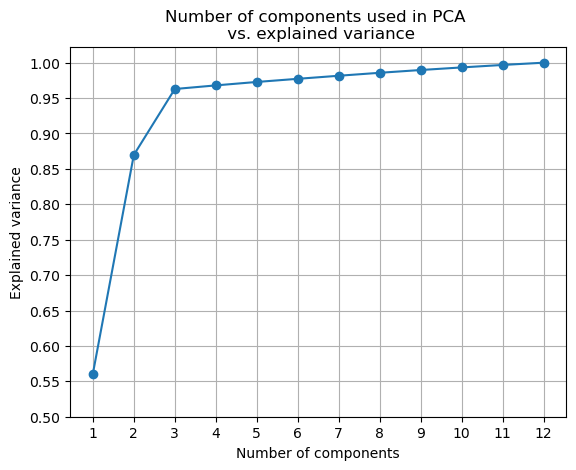

In [5]:
plt.plot(np.arange(1, data.shape[1]+1), var_list, marker='o')
plt.xticks(np.arange(1,12.5,1))
plt.yticks(np.arange(0.5, 1.01, 0.05))  # ticks from 0 to 1 in steps of 0.1
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.title("Number of components used in PCA \n vs. explained variance")
plt.grid(True)
plt.show()

In [6]:
n_cps=3

In [7]:
data_reduced_3=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

In [8]:
print(data.shape,data_reduced_3.shape)
#print(data[10:,:])
#print(data_reduced[:10,:])

(600, 12) (600, 3)


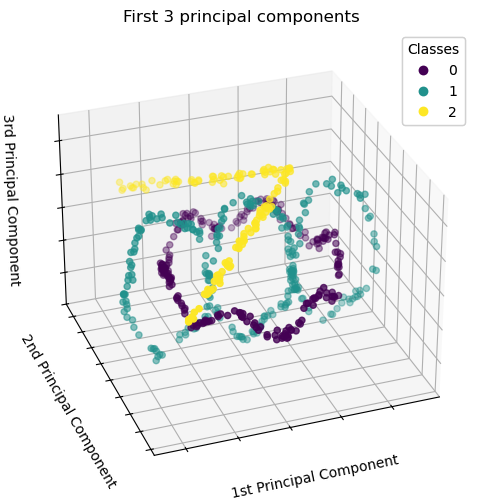

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)


scatter = ax.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True#,
    #s=40,
)

ax.set(
    title=f"First {n_cps} principal components",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend3 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend3)

plt.show()


In [10]:
n_cps=2
data_reduced=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

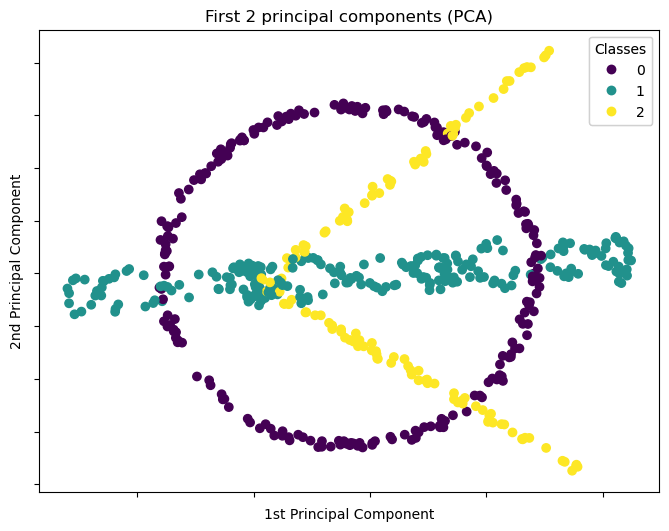

In [11]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)#, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    data_reduced[:, 0],
    data_reduced[:, 1],
    #data_reduced[:, 2],
    c=y#,
    #s=40,
)

ax.set(
    title=f"First {n_cps} principal components (PCA)",
    xlabel="1st Principal Component",
    ylabel="2nd Principal Component",
    #zlabel="3rd Principal Component",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
#ax.zaxis.set_ticklabels([])

# Add a legend
legend2 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend2)

plt.show()

In [12]:
n_cps=1
data_reduced=PCA(n_components=n_cps, whiten=False, svd_solver='full').fit_transform(data,y)

In [13]:
data_reduced.shape

(600, 1)

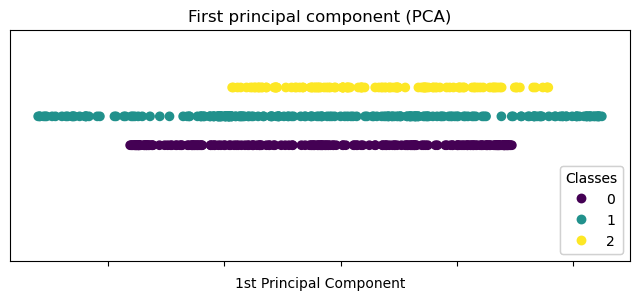

In [14]:
fig = plt.figure(figsize=(8, 3))
ax = fig.add_subplot(111)#, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    data_reduced[:, 0],
    #data_reduced[:, 1],
    #data_reduced[:, 2],
    y=y/4,#np.zeros(data_reduced.shape[0]),
    #---> for plotting
    c=y
    #s=40,
)

ax.set(
    title="First principal component (PCA)",
    xlabel="1st Principal Component",
    ylim=[-1,1]
    #ylabel="2nd Principal Component",
    #zlabel="3rd Principal Component",
)

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.yaxis.set_ticks([])
#ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    np.unique(y),
    loc="lower right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

In [15]:
# ---> TODO: get NMI or similar to numerically (using labels) say how good??

## Try K-means clustering on labelled dataset (Exercise 4.3)

We fix the number of clusters $k=3$. We perform PCA beforehand, in order to make sure that K-means doesn't worry about the noise components when picking clusters.

In [16]:
from sklearn.cluster import KMeans
from collections import OrderedDict

In [17]:
def NMI(y_true, y_pred):
    """ Computes normalized mutual information: where y_true and y_pred are both clustering assignments
    """
    w = clustering(y_true) # clustering of the true labels
    c = clustering(y_pred) # clustering of the predicted labels
    n_sample = len(y_true)

    Iwc = 0. # mutual information between w and c
    for kw in w.keys():
        for kc in c.keys():
            w_intersect_c=len(set(w[kw]).intersection(set(c[kc]))) # number of data points in the intersection of cluster kw and kc
            if w_intersect_c > 0:
                Iwc += w_intersect_c*np.log(n_sample*w_intersect_c/(len(w[kw])*len(c[kc]))) # mutual information contribution of the intersection of cluster kw and kc
    Iwc/=n_sample
    Hc = entropy(c,n_sample) # entropy of the predicted clustering
    Hw = entropy(w,n_sample) # entropy of the true clustering

    return 2*Iwc/(Hc+Hw)

def clustering(y):
    # Finds position of labels and returns a dictionary of cluster labels to data indices.
    yu = np.sort(np.unique(y))
    clustering = OrderedDict()
    for ye in yu:
        clustering[ye] = np.where(y == ye)[0]
    return clustering

def entropy(c, n_sample):
    # Measures the shannon entropy of a cluster
    # c is a dictinary of cluster labels to data indices 
    # n_sample is the total number of data points
    h = 0.
    for kc in c.keys():
        p=len(c[kc])/n_sample
        h+=p*np.log(p)
    h*=-1.
    return h

In [18]:
kmeans=KMeans(n_clusters=3, init='random', n_init=10, max_iter=300, tol=0.0001, verbose=0, algorithm='lloyd').fit(data_reduced_3)
y_hat=kmeans.labels_

Initialization complete
Iteration 0, inertia 361528453.88142633.
Iteration 1, inertia 260415328.73631054.
Iteration 2, inertia 187412206.65663928.
Iteration 3, inertia 155746016.383034.
Iteration 4, inertia 147686376.5729918.
Iteration 5, inertia 146589047.49121886.
Iteration 6, inertia 146052879.16668063.
Converged at iteration 6: center shift 15.238039099061176 within tolerance 19.67914638607231.
Initialization complete
Iteration 0, inertia 212322816.2424788.
Iteration 1, inertia 164409074.1712013.
Iteration 2, inertia 158159960.43695202.
Iteration 3, inertia 157454060.53717405.
Iteration 4, inertia 157135568.90579975.
Iteration 5, inertia 157012833.99968606.
Iteration 6, inertia 156879671.59226292.
Iteration 7, inertia 156458884.17126912.
Iteration 8, inertia 155387353.1656086.
Iteration 9, inertia 152924514.9594878.
Iteration 10, inertia 150505852.93405464.
Iteration 11, inertia 148336550.7675817.
Iteration 12, inertia 146793166.17042804.
Iteration 13, inertia 146238408.42494082.
I

In [19]:
centroids=kmeans.cluster_centers_

In [20]:
y_hat=kmeans.predict(data_reduced_3)
nmi=NMI(y_hat, y)
print(nmi)
print(data_reduced_3.shape)

0.1262461683689528
(600, 3)


C:\Users\Libero\AppData\Local\Temp\ipykernel_1368\3027106974.py:53: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


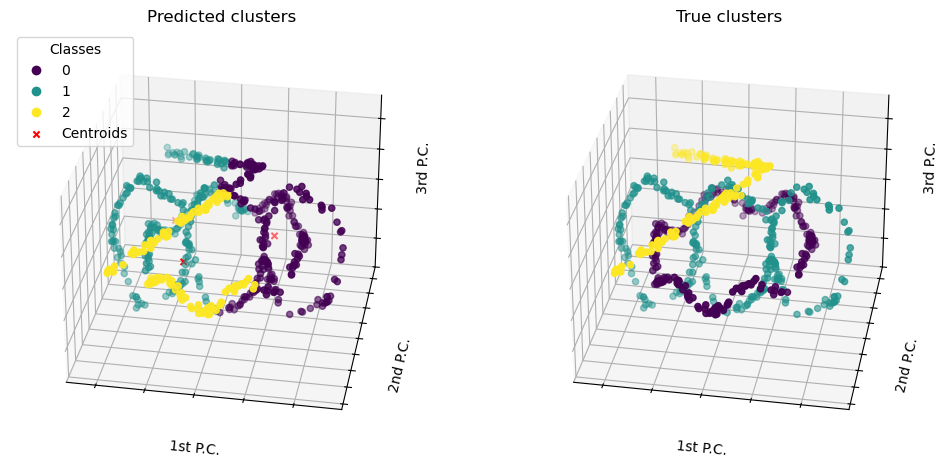

In [21]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2 , projection="3d", elev=-150, azim=80)

scatter1=ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)

scatter1b=ax1.scatter(centroids[:,0], centroids[:,1], centroids[:,2], marker='x', c='r', label="Centroids")

ax1.set(
    title="Predicted clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)

ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

handles1, labels1 = scatter1.legend_elements()
handles1.append(scatter1b)
labels1.append("Centroids")
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True#,
    #s=40,
)

ax2.set(
    title="True clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

# Add a legend
#handles2, labels2 = scatter2.legend_elements()
#ax2.legend(handles2, labels2, title="Classes", loc="upper left")

plt.tight_layout()
plt.show()

In [22]:
print(centroids, '\n\n', nmi)

[[-578.64655346   62.28358812   -1.83017778]
 [ 494.62819643  258.48251715   31.0185643 ]
 [ 199.78267483 -621.95330692  -56.10351975]] 

 0.1262461683689528


## Try hierarchical clustering (Exercise 4.4)

As before, we perform PCA beforehand.

In [23]:
from sklearn.cluster import AgglomerativeClustering as HC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd

In [24]:
my_linkages=['ward', 'complete', 'average', 'single']
my_metrics=['euclidean', 'l1', 'l2', 'manhattan', 'cosine']
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data_reduced_3) # ---> rescale 3d (post-PCA) data for better implementation

### Compare different metrics and linkages to find best output

In [25]:
best_model=''
scores=[]
models=[]
score_best=-1e9
for mc in my_metrics:
    for lk in my_linkages:
        if ((lk=='ward') and (mc!='euclidean')): continue
        hc_model=HC(n_clusters=3, metric=mc, linkage=lk, compute_distances=True)
        cluster_labels = hc_model.fit_predict(scaled_data)
        #pd.Series(cluster_labels).value_counts()
        sil_score = silhouette_score(scaled_data, cluster_labels)
        #print("Score :", round(sil_score, 2))
        if (sil_score>score_best):
            score_best=sil_score
            best_model=hc_model
        scores.append(sil_score)

In [27]:
#print([float(score) for score in scores], '\n')
print(score_best, '\n')
print(best_model, '\n')

y_hat=best_model.labels_
nmi=NMI(y_hat, y)
print(nmi)

0.27899310356666435 

AgglomerativeClustering(compute_distances=True, linkage='average',
                        metric='cosine', n_clusters=3) 

0.25158051075398297


In [28]:
#---> TODO: plot results (heatmap)??

### Visualise the dendrogram
(for the best model).

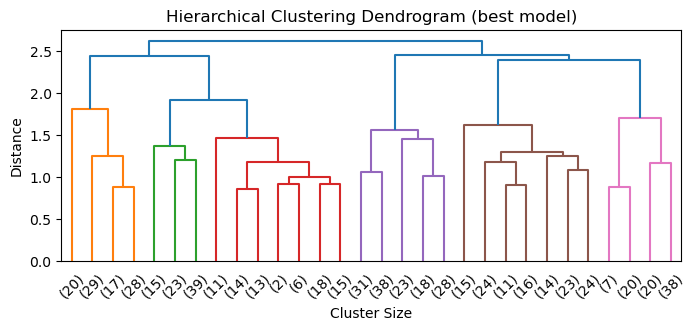

In [29]:
linked = linkage(scaled_data, method='average')

plt.figure(figsize=(8, 3))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30
)
plt.title("Hierarchical Clustering Dendrogram (best model)")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

C:\Users\Libero\AppData\Local\Temp\ipykernel_1368\4073233508.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


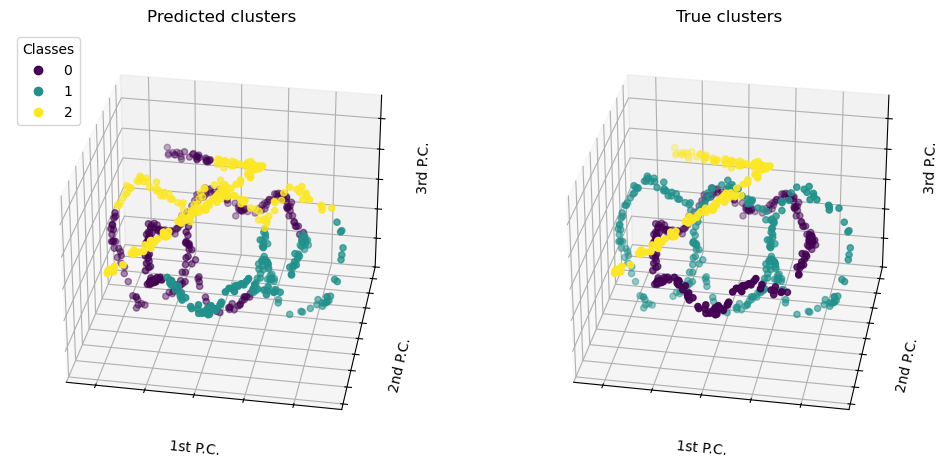

In [30]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2 , projection="3d", elev=-150, azim=80)

scatter1=ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)

ax1.set(
    title="Predicted clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)

ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

handles1, labels1 = scatter1.legend_elements()
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True#,
    #s=40,
)

ax2.set(
    title="True clusters",
    xlabel="1st P.C.",
    ylabel="2nd P.C.",
    zlabel="3rd P.C.",
)
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

# Add a legend
#handles2, labels2 = scatter2.legend_elements()
#ax2.legend(handles2, labels2, title="Classes", loc="upper left")

plt.tight_layout()
plt.show()

### Try spectral clustering (Exercise 4.5)

Performs clustering (eg with k-means) on a *map* of original data (a projection of the normalized Laplacian), to distinguish clusters by their characteristic shape. As before, we perform PCA beforehand.

In [41]:
from sklearn.cluster import SpectralClustering as SC
from sklearn.manifold import SpectralEmbedding as SE #---> for visualisation later
from time import time
from scipy.optimize import linear_sum_assignment #---> for label remapping
from sklearn.metrics import confusion_matrix #---> for label remapping
#---> review these last two??

In [42]:
def remap_labels(y_true, y_pred):
    #---> function to remap predicted lables as to align them with the true ones (used later for plotting)
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)  #---> maximize overlap
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    return np.array([mapping[label] for label in y_pred])

In [32]:
print(scaled_data.shape)

(600, 3)


In [35]:
gammas=[0.001,0.01,0.1,1,10,100]
nmi_list=[]
nmi_best=-0.1
gamma_best=0

start=time()
# rbf kernel with different gammas
for g in gammas:
    y_hat=SC(n_clusters=3,
       n_init=10, # number of iters for assigning_labels='kmeans'
       gamma=g, # kernel coefficient for rbf, poly, sigmoid, laplacian and chi2 kernels
       eigen_solver='arpack', # computational strategy ('arpack' is deterministic)
       affinity='rbf', # kernel to use to calculate the affinity matrix
       n_neighbors=10, # for nearest-neighbor method of assigning labels
       eigen_tol='auto', # eigen_tol=0.0 for arpack
       assign_labels='kmeans', # strategy to assign labels, ie to perform clustering in the embedded space
       degree=3, # degree for poly kernel only
       coef0=1, # for poly and sigmoid kernels only
       verbose=False).fit_predict(scaled_data)
    nmi=NMI(y_hat,y)
    if (nmi>nmi_best):
        nmi_best=nmi
        gamma_best=g
    nmi_list.append(nmi)
end=time()
tot_time=end-start
print([float(n) for n in nmi_list], '\n')
print("Computational time:", tot_time, "s")

[0.21434750471469416, 0.214660245960514, 0.20584074437890154, 0.25635226467216754, 0.46565193644674907, 0.16229395501690713] 

Computational time: 39.24965953826904


C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited at iteration 2000 with accuracies 
[4.28440645e-15 1.91028137e-06 3.85479093e-06 1.61236038e-05]
not reaching the requested tolerance 8.940696716308594e-06.
Use iteration 1836 instead with accuracy 
3.6957136357111774e-06.

  _, diffusion_map = lobpcg(
C:\Users\Libero\anaconda3\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[3.84435733e-15 1.93864306e-06 3.70328224e-06 9.14125530e-06]
not reaching the requested tolerance 8.940696716308594e-06.
  _, diffusion_map = lobpcg(


In [36]:
print(nmi_best)
print(gamma_best)

0.46565193644674907
10


In [37]:
# nearest neighbors kernel
y_hat=SC(n_clusters=3,
   n_init=10, # number of iters for assigning_labels='kmeans'
   eigen_solver='arpack', # computational strategy ('arpack' is deterministic)
   affinity='nearest_neighbors', # kernel to use to calculate the affinity matrix
   n_neighbors=10, # for nearest-neighbor method of assigning labels
   eigen_tol='auto', # eigen_tol=0.0 for arpack
   assign_labels='kmeans', # strategy to assign labels, ie to perform clustering in the embedded space
   verbose=False).fit_predict(scaled_data)
nmi=NMI(y_hat,y)
print(nmi)

0.9617394647100063


In [38]:
#---> TODO: further improve (but might risk overfitting)?

In [43]:
y_hat = remap_labels(y, y_hat)

(5,)


C:\Users\Libero\AppData\Local\Temp\ipykernel_1368\2991958957.py:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


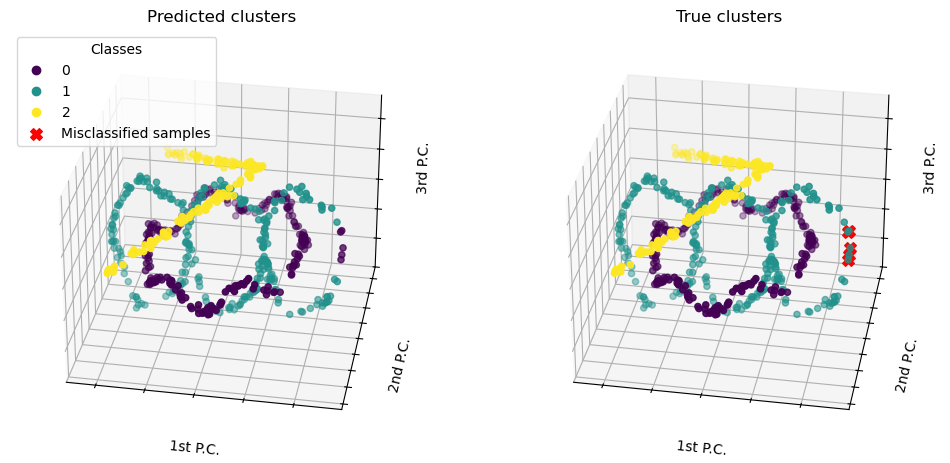

In [44]:
fig = plt.figure(figsize=(12, 10))
ax1 = fig.add_subplot(1,2,1, projection="3d", elev=-150, azim=80)
ax2 = fig.add_subplot(1,2,2, projection="3d", elev=-150, azim=80)

scatter1 = ax1.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y_hat,
    depthshade=True)
ax1.set(title="Predicted clusters", xlabel="1st P.C.", ylabel="2nd P.C.", zlabel="3rd P.C.")
ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

scatter2 = ax2.scatter(
    data_reduced_3[:, 0],
    data_reduced_3[:, 1],
    data_reduced_3[:, 2],
    c=y,
    depthshade=True)
ax2.set(title="True clusters", xlabel="1st P.C.", ylabel="2nd P.C.", zlabel="3rd P.C.")
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

miscl_mask = [y_hat != y]
scatter3 = ax2.scatter(
    data_reduced_3[miscl_mask[0], 0],
    data_reduced_3[miscl_mask[0], 1],
    data_reduced_3[miscl_mask[0], 2],
    c='r',
    depthshade=False,
    s=70,
    marker='X',
    #zorder=10,
    label='Misclassified samples')

handles1, labels1 = scatter1.legend_elements()
handles1.append(scatter3)
labels1.append('Misclassified samples')
ax1.legend(handles1, labels1, title="Classes", loc="upper left")

print(data_reduced_3[miscl_mask[0], 0].shape)

plt.tight_layout()
plt.show()

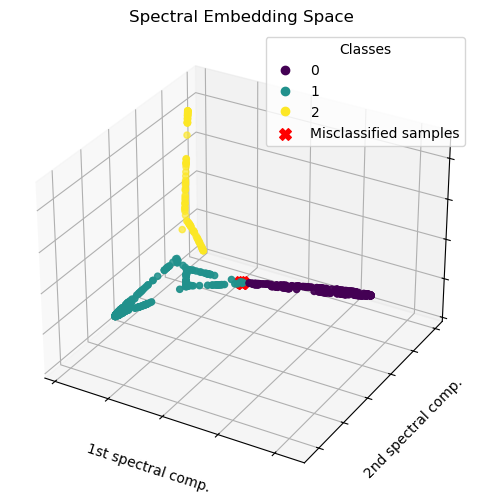

In [45]:
#--->visualise the embedding space:

se = SE(n_components=3, affinity='nearest_neighbors', n_neighbors=10) #---> exactly the same algorithm used inside SC 
embedding = se.fit_transform(scaled_data)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
scatter=ax.scatter(embedding[:, 0], embedding[:, 1], embedding[:, 2], c=y)
scatter_m = ax.scatter(
    embedding[miscl_mask[0], 0],
    embedding[miscl_mask[0], 1],
    embedding[miscl_mask[0], 2],
    c='r',
    depthshade=False,
    s=70,
    marker='X',
    #zorder=10,
    label='Misclassified samples')

ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set(title="Spectral Embedding Space", xlabel="1st spectral comp.", ylabel="2nd spectral comp.", zlabel="3rd spectral comp.")
handles, labels = scatter.legend_elements()
handles.append(scatter_m)
labels.append('Misclassified samples')

ax.legend(handles, labels, title="Classes", loc="upper right")
plt.show()

In [36]:
# ---> TODO (all): review both technical (esp. spectral embedding) and plotting details?;
#      prettier graphs /code?
#      explain??